# EDA KIMORE
Il minimo necessario per decidere task, split e da quale esercizio partire.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
with open(ROOT / "data" / "raw" / "kimore" / "kimore_exercise_dataset.pkl", "rb") as f:
    data = pickle.load(f)
list(data.keys())

['ex1', 'ex2', 'ex3', 'ex4', 'ex5']

## Soggetti e frame per esercizio

In [2]:
rows = []
for ex, df in data.items():
    n_frames = df["spinebase"].apply(lambda a: np.asarray(a).shape[0])
    rows.append({"esercizio": ex, "n_soggetti": len(df),
                 "frame_min": n_frames.min(), "frame_mean": round(n_frames.mean()),
                 "frame_max": n_frames.max()})
pd.DataFrame(rows).set_index("esercizio")

,n_soggetti,frame_min,frame_mean,frame_max
esercizio,,,,
ex1,77,288,731,2487
ex2,75,182,808,1664
ex3,75,364,813,1517
ex4,76,349,839,1990
ex5,75,273,556,1020


## Distribuzione cTS (punteggio clinico)
Quanto e' sbilanciata? Regressione o classificazione?

In [3]:
stats = pd.DataFrame({ex: df["cTS"].describe() for ex, df in data.items()})
stats.loc[["min", "mean", "max", "std"]]

,ex1,ex2,ex3,ex4,ex5
min,0.500000,0.500000,0.500000,0.500000,0.500000
mean,0.883030,0.881689,0.881689,0.881842,0.881689
max,1.000000,1.000000,1.000000,1.000000,1.000000
std,0.100307,0.101094,0.101094,0.100426,0.101094


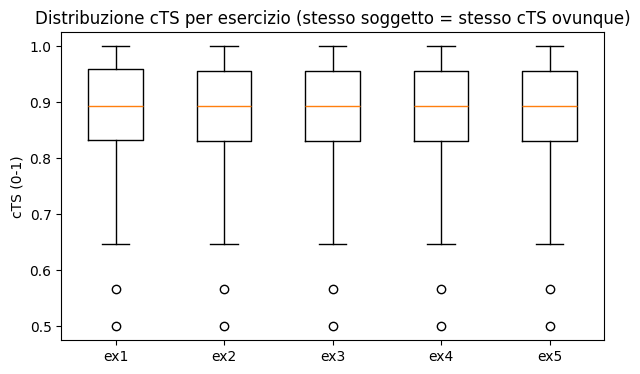

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([data[ex]["cTS"] for ex in data], tick_labels=list(data.keys()))
ax.set_ylabel("cTS (0-1)")
ax.set_title("Distribuzione cTS per esercizio (stesso soggetto = stesso cTS ovunque)")
plt.show()

## Il cTS e per soggetto o per esecuzione?
Se e identico su tutti gli esercizi, e un punteggio clinico generale del paziente, non uno score specifico di quella singola esecuzione.

In [5]:
import itertools

pairs = list(itertools.combinations(data.keys(), 2))
same_length = [(a, b) for a, b in pairs if len(data[a]) == len(data[b])]
skipped = [(a, b) for a, b in pairs if len(data[a]) != len(data[b])]

all_equal = all((data[a]["cTS"].reset_index(drop=True)
                  == data[b]["cTS"].reset_index(drop=True)).all() for a, b in same_length)
print(f"cTS identico su {len(same_length)}/{len(pairs)} coppie con lo stesso n. di soggetti:", all_equal)
if skipped:
    sizes = {ex: len(df) for ex, df in data.items()}
    print(f"Non confrontabili posizionalmente (n. soggetti diverso): "
          f"{[(a, sizes[a], b, sizes[b]) for a, b in skipped]}")

cTS identico su 3/10 coppie con lo stesso n. di soggetti: True
Non confrontabili posizionalmente (n. soggetti diverso): [('ex1', 77, 'ex2', 75), ('ex1', 77, 'ex3', 75), ('ex1', 77, 'ex4', 76), ('ex1', 77, 'ex5', 75), ('ex2', 75, 'ex4', 76), ('ex3', 75, 'ex4', 76), ('ex4', 76, 'ex5', 75)]


## Sanity check: il segnale ha davvero il pattern del movimento atteso?
ex1 = sollevamento braccia (wristleft) - ex5 = squat (kneeleft)

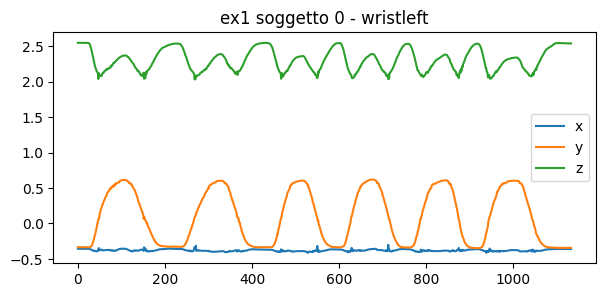

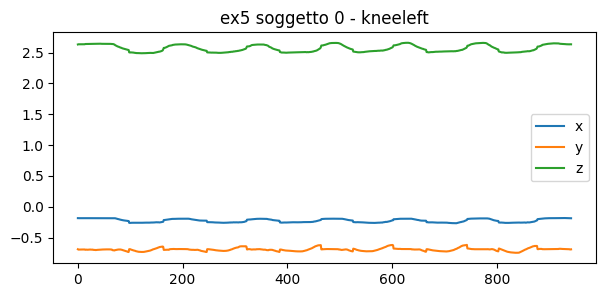

In [6]:
def plot_traj(ex, joint, subj=0):
    arr = np.asarray(data[ex][joint].iloc[subj])
    pos = arr[:, 4:7]
    fig, ax = plt.subplots(figsize=(7, 3))
    for i, c in enumerate(["x", "y", "z"]):
        ax.plot(pos[:, i], label=c)
    ax.set_title(f"{ex} soggetto {subj} - {joint}")
    ax.legend(); plt.show()

plot_traj("ex1", "wristleft")
plot_traj("ex5", "kneeleft")

## Conclusioni operative
- **Task:** regressione su cTS (sbilanciamento moderato, non estremo).
- **Split:** per soggetto, dentro un singolo esercizio (nessuna riga duplicata).
- **cTS e per-soggetto**, non per-esecuzione: da dichiarare come limite onesto.
- **Si parte da un solo esercizio (ex5, squat)** per tenere il primo giro pulito e piccolo.